<a href="https://colab.research.google.com/github/18felasofa/Analisis-Deret-Waktu/blob/main/Tugas_Kelompok_Minggu_4_rev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Install terlebih dahulu package PythonTsa
!pip install PythonTsa

# menginstall package pydataset
!pip install pydataset

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 441.1/441.1 kB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 41.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939458 sha256=8729e83170bbf4e11223690e1f9cfc187992e3d5a9cd215b04739bc44be4f85c
  Stored in directory: /root/.cache/pip/wheels/49/2a/45/180e1199b8d925b5c43df8f9850dcc2e5dfc94e3e99a55b83e
Successfully built pydataset


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, boxcox
from scipy.special import inv_boxcox
from statsmodels.tsa.stattools import acf, adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

In [3]:
# Import library
import pandas as pd
import matplotlib.pyplot as plt

# URL raw GitHub
url = "https://raw.githubusercontent.com/lailynissa/StatistikaSainsData/main/penumpang%20pesawat%20Soeta.csv"

# Membaca data CSV
df_soetta = pd.read_csv(url)

# Menampilkan 5 baris awal data
df_soetta.head()

,Waktu,Total
0,31/01/2010,1176478
1,28/02/2010,1100169
2,31/03/2010,1225671
3,30/04/2010,1206909
4,31/05/2010,1292549


In [4]:
# Melihat jumlah baris dan kolom
print("Ukuran data:", df_soetta.shape)

# Melihat informasi struktur data
df_soetta.info()

Ukuran data: (137, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Waktu   137 non-null    object
 1   Total   137 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.3+ KB


In [5]:
# Melihat nama kolom
df_soetta.columns

Index(['Waktu', 'Total'], dtype='object')

In [6]:
# Mengubah tipe data kolom Waktu menjadi datetime
df_soetta['Waktu'] = pd.to_datetime(
    df_soetta['Waktu'],
    format='%d/%m/%Y'
)

# Mengurutkan data berdasarkan waktu
df_soetta = df_soetta.sort_values(by='Waktu').reset_index(drop=True)

# Mengecek kembali struktur data
df_soetta.info()

# Menampilkan 5 baris awal
df_soetta.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Waktu   137 non-null    datetime64[ns]
 1   Total   137 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.3 KB


,Waktu,Total
0,2010-01-31,1176478
1,2010-02-28,1100169
2,2010-03-31,1225671
3,2010-04-30,1206909
4,2010-05-31,1292549


In [7]:
# Melihat periode pengamatan dan jumlah observasi
print("Periode awal :", df_soetta['Waktu'].min())
print("Periode akhir:", df_soetta['Waktu'].max())
print("Jumlah pengamatan:", len(df_soetta))

Periode awal : 2010-01-31 00:00:00
Periode akhir: 2021-05-31 00:00:00
Jumlah pengamatan: 137


In [8]:
# Mengecek missing value
print("Missing value:")
print(df_soetta.isnull().sum())

# Mengecek data duplikat
print("\nJumlah data duplikat:", df_soetta.duplicated().sum())

Missing value:
Waktu    0
Total    0
dtype: int64

Jumlah data duplikat: 0


In [9]:
# Menampilkan statistik deskriptif variabel Total
df_soetta['Total'].describe()

,Total
count,1.370000e+02
mean,1.525133e+06
std,4.069895e+05
min,2.750000e+04
25%,1.418207e+06
50%,1.643796e+06
75%,1.774351e+06
max,2.132360e+06


## 1. Data asli tanpa penanganan outlier

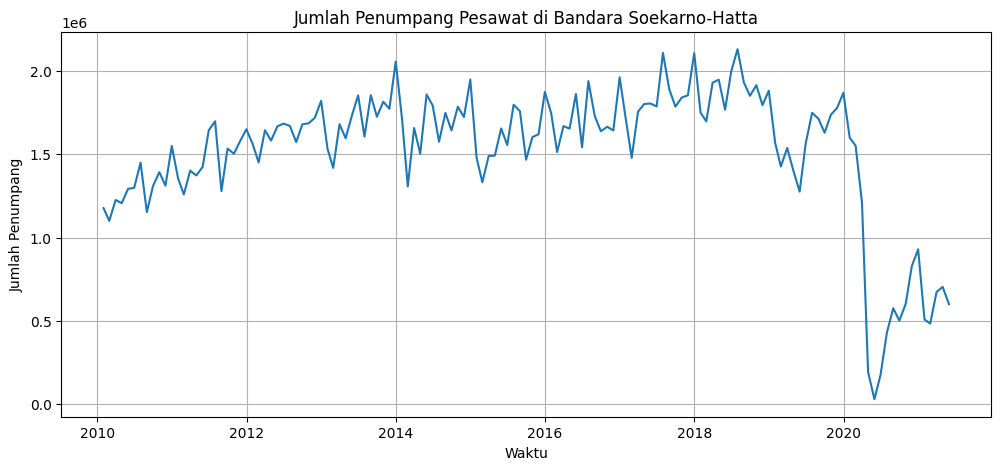

In [10]:
# Membuat plot deret waktu
plt.figure(figsize=(12, 5))
plt.plot(df_soetta['Waktu'], df_soetta['Total'])
plt.title('Jumlah Penumpang Pesawat di Bandara Soekarno-Hatta')
plt.xlabel('Waktu')
plt.ylabel('Jumlah Penumpang')
plt.grid(True)
plt.show()

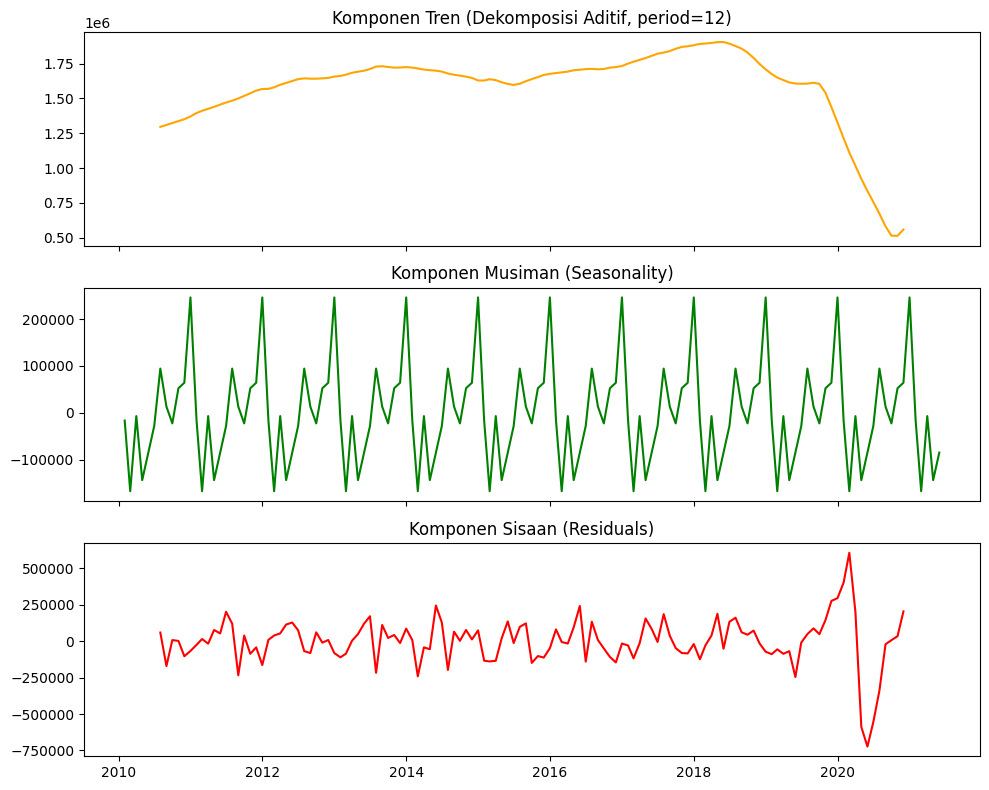

In [11]:
decomp = seasonal_decompose( df_soetta['Total'], model='additive', period=12)
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(df_soetta['Waktu'], decomp.trend, color='orange')
axes[0].set_title(f"Komponen Tren (Dekomposisi Aditif, period={12})")
axes[1].plot(df_soetta['Waktu'], decomp.seasonal, color='green')
axes[1].set_title("Komponen Musiman (Seasonality)")
axes[2].plot(df_soetta['Waktu'], decomp.resid, color='red')
axes[2].set_title("Komponen Sisaan (Residuals)")
plt.tight_layout()

Berdasarkan plot deret waktu, jumlah penumpang pesawat di Bandara Soekarno-Hatta menunjukkan kecenderungan meningkat dari tahun 2010 hingga sekitar 2018–2019, meskipun terdapat fluktuasi pada setiap periode. Pola kenaikan dan penurunan yang muncul secara berulang juga memberikan indikasi adanya pola musiman. Perubahan yang paling menonjol terjadi pada tahun 2020 ketika jumlah penumpang menurun sangat tajam dibandingkan periode sebelumnya. Setelah tahun 2020 jumlah penumpang mulai mengalami peningkatan kembali. Secara visual, deret waktu ini menunjukkan adanya tren, kemungkinan pola musiman, serta perubahan pola yang cukup besar sekitar tahun 2020. Oleh karena itu, deret belum menunjukkan pola yang stabil sepanjang periode pengamatan.

<Figure size 1000x500 with 0 Axes>

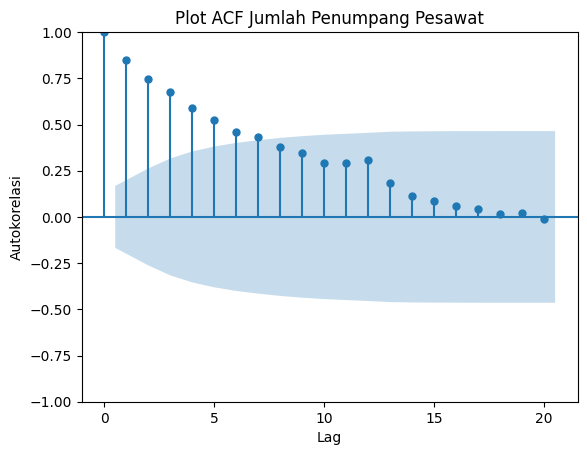

In [12]:
# Import fungsi untuk plot ACF dan PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF
plt.figure(figsize=(10, 5))
plot_acf(df_soetta['Total'], lags=20)
plt.title('Plot ACF Jumlah Penumpang Pesawat')
plt.xlabel('Lag')
plt.ylabel('Autokorelasi')
plt.show()

<Figure size 1000x500 with 0 Axes>

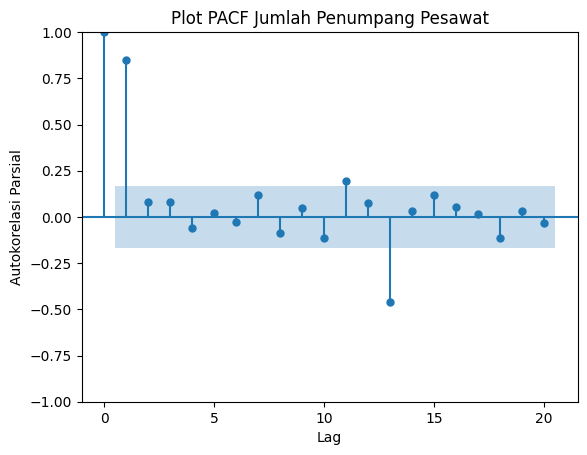

In [13]:
# Plot PACF
plt.figure(figsize=(10, 5))
plot_pacf(df_soetta['Total'], lags=20, method='ywm')
plt.title('Plot PACF Jumlah Penumpang Pesawat')
plt.xlabel('Lag')
plt.ylabel('Autokorelasi Parsial')
plt.show()

Berdasarkan plot ACF dan PACF, deret jumlah penumpang pesawat menunjukkan indikasi belum stasioner. Hal ini terlihat pada plot ACF, yaitu nilai autokorelasi pada lag awal masih tinggi dan menurun secara bertahap hingga beberapa lag berikutnya. Pola tersebut menunjukkan bahwa pengamatan pada suatu periode masih memiliki hubungan yang cukup kuat dengan pengamatan periode sebelumnya. Pada plot PACF, autokorelasi parsial yang paling tinggi terlihat pada lag 1, sedangkan sebagian besar lag berikutnya berada di sekitar nol. Meskipun demikian, kesimpulan mengenai stasioneritas sebaiknya dikonfirmasi menggunakan uji formal, seperti Augmented Dickey-Fuller (ADF) atau KPSS.

In [14]:
# Uji unit-root Augmented Dickey Fuller
from statsmodels.tsa.stattools import adfuller

hasil_adf = adfuller(df_soetta['Total'])

print("ADF Statistic :", hasil_adf[0])
print("p-value       :", hasil_adf[1])

if hasil_adf[1] < 0.05:
    print("Kesimpulan: Tolak H0, deret stasioner.")
else:
    print("Kesimpulan: Gagal menolak H0, deret belum stasioner.")

ADF Statistic : -1.5964112702187934
p-value       : 0.485395977870123
Kesimpulan: Gagal menolak H0, deret belum stasioner.


/tmp/ipykernel_1205/3685777162.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  hasil_adf = adfuller(df_soetta['Total'])


Berdasarkan hasil uji Augmented Dickey-Fuller (ADF), diperoleh nilai ADF Statistic sebesar -1,5964 dengan p-value sebesar 0,4854. Karena p-value lebih besar dari taraf signifikansi 0,05, maka Hipotesis  0 gagal ditolak. Dengan demikian, deret jumlah penumpang pesawat belum stasioner. Hasil ini sejalan dengan pola pada plot ACF yang menunjukkan autokorelasi cukup tinggi pada beberapa lag awal dan menurun secara bertahap.

In [15]:
# Membuat salinan data asli
df_boxfirst = df_soetta[['Waktu', 'Total']].copy()

print("Jumlah observasi:", len(df_boxfirst))
df_boxfirst.head()

Jumlah observasi: 137


,Waktu,Total
0,2010-01-31,1176478
1,2010-02-28,1100169
2,2010-03-31,1225671
3,2010-04-30,1206909
4,2010-05-31,1292549


In [16]:
# Mengecek nilai minimum
print("Nilai minimum Total:", df_boxfirst['Total'].min())
print("Jumlah nilai <= 0:", (df_boxfirst['Total'] <= 0).sum())

Nilai minimum Total: 27500
Jumlah nilai <= 0: 0


In [17]:
# Transformasi Box-Cox pada data asli
from scipy.stats import boxcox

total_boxcox, lambda_fit, ci = boxcox(
    df_boxfirst['Total'],
    alpha=0.05
)

print("Nilai lambda :", lambda_fit)
print("Interval kepercayaan lambda :", ci)

Nilai lambda : 2.3435889368164857
Interval kepercayaan lambda : (1.8802631131479335, 2.8548120317492605)


In [18]:
# Menyimpan hasil transformasi Box-Cox
df_boxfirst['Total_BoxCox'] = total_boxcox

df_boxfirst[['Waktu', 'Total', 'Total_BoxCox']].head()

,Waktu,Total,Total_BoxCox
0,2010-01-31,1176478,7.195676e+13
1,2010-02-28,1100169,6.149163e+13
2,2010-03-31,1225671,7.920713e+13
3,2010-04-30,1206909,7.639478e+13
4,2010-05-31,1292549,8.970945e+13


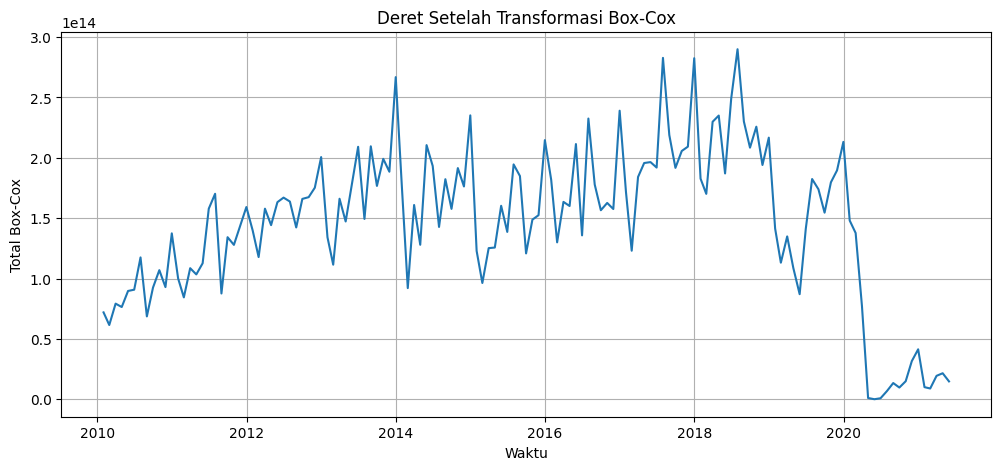

In [19]:
# Plot deret setelah transformasi Box-Cox
plt.figure(figsize=(12, 5))
plt.plot(
    df_boxfirst['Waktu'],
    df_boxfirst['Total_BoxCox']
)
plt.title('Deret Setelah Transformasi Box-Cox')
plt.xlabel('Waktu')
plt.ylabel('Total Box-Cox')
plt.grid(True)
plt.show()

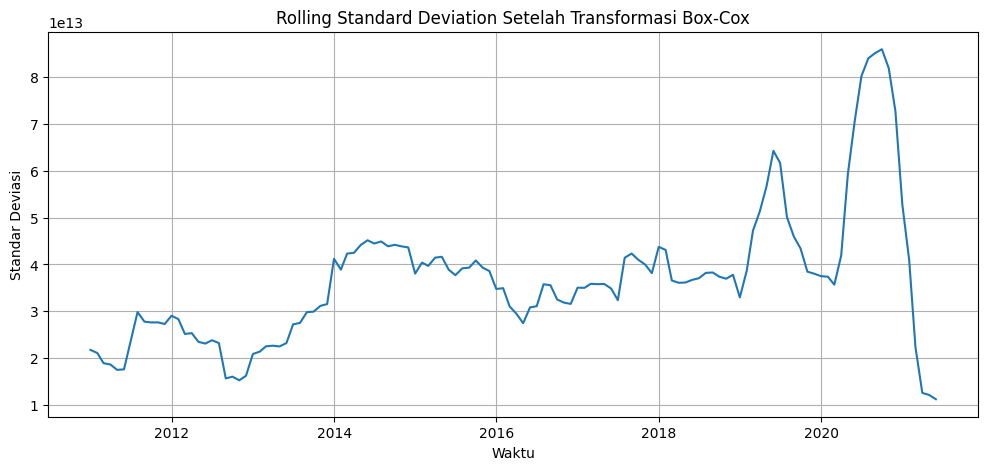

In [20]:
# Rolling standard deviation setelah Box-Cox
rolling_std_boxfirst = (
    df_boxfirst['Total_BoxCox']
    .rolling(window=12)
    .std()
)

plt.figure(figsize=(12, 5))

plt.plot(
    df_boxfirst['Waktu'],
    rolling_std_boxfirst
)

plt.title('Rolling Standard Deviation Setelah Transformasi Box-Cox')
plt.xlabel('Waktu')
plt.ylabel('Standar Deviasi')
plt.grid(True)
plt.show()

In [21]:
# Uji ADF setelah transformasi Box-Cox
hasil_adf_boxfirst = adfuller(
    df_boxfirst['Total_BoxCox'],
    result_object=False
)

print("ADF Statistic :", hasil_adf_boxfirst[0])
print("p-value       :", hasil_adf_boxfirst[1])

if hasil_adf_boxfirst[1] < 0.05:
    print("Kesimpulan: Tolak H0, deret sudah stasioner dalam nilai tengah.")
else:
    print("Kesimpulan: Gagal menolak H0, deret belum stasioner dalam nilai tengah.")

ADF Statistic : -1.2961352649842777
p-value       : 0.6309385745778369
Kesimpulan: Gagal menolak H0, deret belum stasioner dalam nilai tengah.


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/stattools/_stattools.py:149: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  results[lag] = mod_instance.fit()
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/stattools/_stattools.py:149: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  results[lag] = mod_instance.fit()
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/stattools/_stattools.py:149: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  results[lag] = mod_instance.fit()
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/stattools/_stattools.py:149: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  results[lag] = mod_instance.fit()
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/stattools/_stattools

In [22]:
# Differencing orde pertama setelah transformasi Box-Cox
df_boxfirst['Diff_1_BoxCox'] = df_boxfirst['Total_BoxCox'].diff()

df_boxfirst_diff = df_boxfirst.dropna().copy()

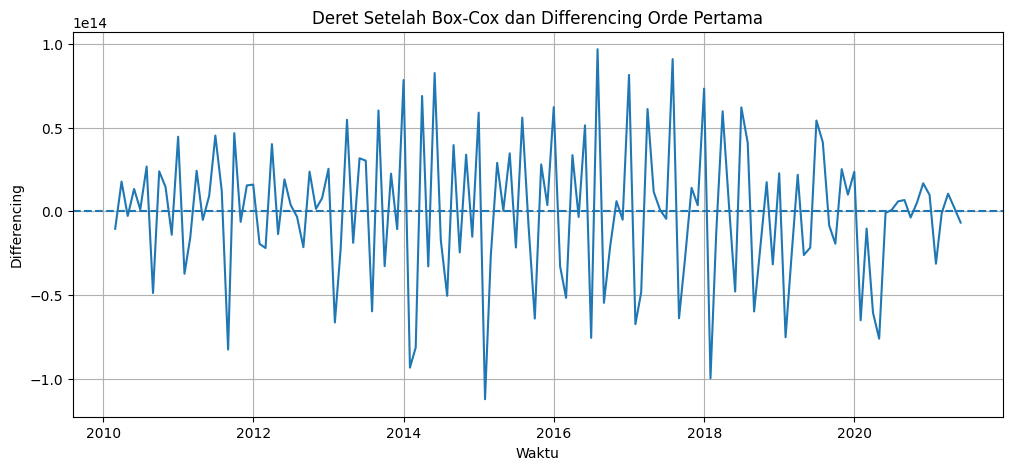

In [23]:
# Plot setelah Box-Cox dan differencing orde pertama
plt.figure(figsize=(12, 5))

plt.plot(
    df_boxfirst_diff['Waktu'],
    df_boxfirst_diff['Diff_1_BoxCox']
)

plt.axhline(y=0, linestyle='--')
plt.title('Deret Setelah Box-Cox dan Differencing Orde Pertama')
plt.xlabel('Waktu')
plt.ylabel('Differencing')
plt.grid(True)
plt.show()

In [24]:
# Uji ADF setelah Box-Cox dan differencing orde pertama
hasil_adf_box_diff = adfuller(
    df_boxfirst_diff['Diff_1_BoxCox'],
    result_object=False
)

print("ADF Statistic :", hasil_adf_box_diff[0])
print("p-value       :", hasil_adf_box_diff[1])

if hasil_adf_box_diff[1] < 0.05:
    print("Kesimpulan: Tolak H0, deret sudah stasioner dalam nilai tengah.")
else:
    print("Kesimpulan: Gagal menolak H0, deret masih belum stasioner dalam nilai tengah.")

ADF Statistic : -3.4849110714579523
p-value       : 0.00838317193341271
Kesimpulan: Tolak H0, deret sudah stasioner dalam nilai tengah.


Setelah dilakukan transformasi Box-Cox dan differencing orde pertama, diperoleh nilai ADF Statistic sebesar -3,4849 dengan p-value sebesar 0,0084. Karena p-value lebih kecil dari taraf signifikansi 0,05, maka H0 ditolak. Dengan demikian, deret setelah transformasi Box-Cox dan differencing orde pertama telah stasioner dalam nilai tengah dan ragam.

## 2. Data training-testing 90:10

In [25]:
# Membagi data menjadi 90% training dan 10% testing
n_total = len(df_soetta)
n_train = int(n_total * 0.90)

df_train = df_soetta.iloc[:n_train].copy()
df_test = df_soetta.iloc[n_train:].copy()

print("Jumlah seluruh data :", n_total)
print("Jumlah data training:", len(df_train))
print("Jumlah data testing :", len(df_test))

print("\nPeriode training:",
      df_train['Waktu'].min(), "sampai", df_train['Waktu'].max())

print("Periode testing :",
      df_test['Waktu'].min(), "sampai", df_test['Waktu'].max())

Jumlah seluruh data : 137
Jumlah data training: 123
Jumlah data testing : 14

Periode training: 2010-01-31 00:00:00 sampai 2020-03-31 00:00:00
Periode testing : 2020-04-30 00:00:00 sampai 2021-05-31 00:00:00


In [26]:
# Mengecek syarat transformasi Box-Cox pada data training
print("Nilai minimum training :", df_train['Total'].min())
print("Jumlah nilai <= 0      :", (df_train['Total'] <= 0).sum())

Nilai minimum training : 1100169
Jumlah nilai <= 0      : 0


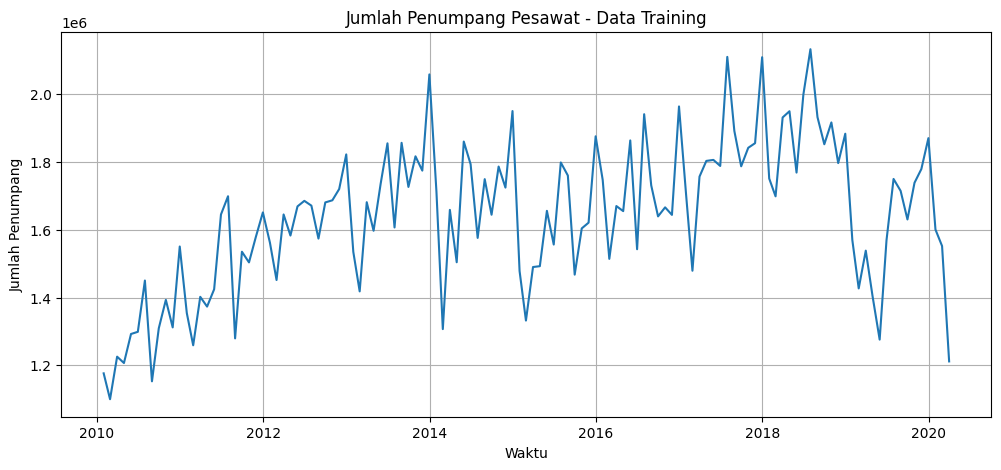

In [27]:
# Plot data training
plt.figure(figsize=(12, 5))

plt.plot(df_train['Waktu'], df_train['Total'])

plt.title('Jumlah Penumpang Pesawat - Data Training')
plt.xlabel('Waktu')
plt.ylabel('Jumlah Penumpang')
plt.grid(True)
plt.show()

<Figure size 1000x500 with 0 Axes>

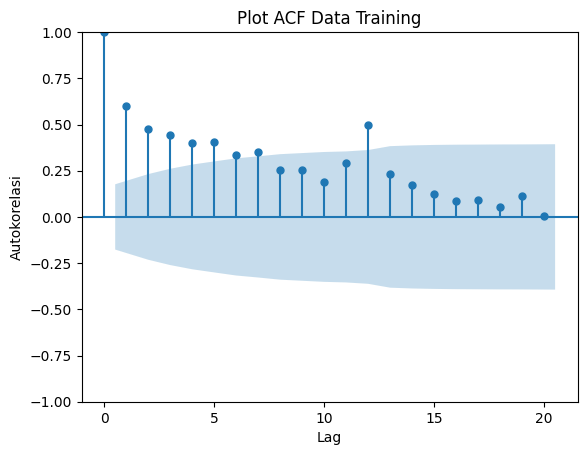

In [28]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF data training
plt.figure(figsize=(10, 5))
plot_acf(df_train['Total'], lags=20)
plt.title('Plot ACF Data Training')
plt.xlabel('Lag')
plt.ylabel('Autokorelasi')
plt.show()

<Figure size 1000x500 with 0 Axes>

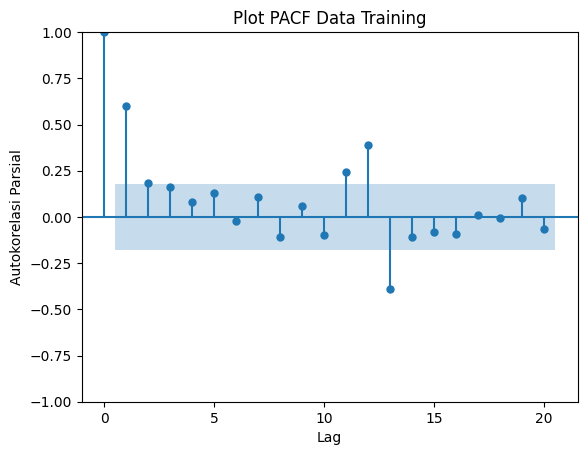

In [29]:
# Plot PACF data training
plt.figure(figsize=(10, 5))
plot_pacf(df_train['Total'], lags=20, method='ywm')
plt.title('Plot PACF Data Training')
plt.xlabel('Lag')
plt.ylabel('Autokorelasi Parsial')
plt.show()

In [30]:
from scipy.stats import boxcox

# Mencari lambda optimal berdasarkan data training
train_boxcox, lambda_train, ci = boxcox(
    df_train['Total'],
    alpha=0.05
)

print("Nilai lambda :", lambda_train)
print("Interval kepercayaan lambda :", ci)

Nilai lambda : 1.6483909621643227
Interval kepercayaan lambda : (0.5088366654740064, 2.8075927317608427)


In [31]:
# Menyimpan hasil Box-Cox data training
df_train['Total_BoxCox'] = train_boxcox

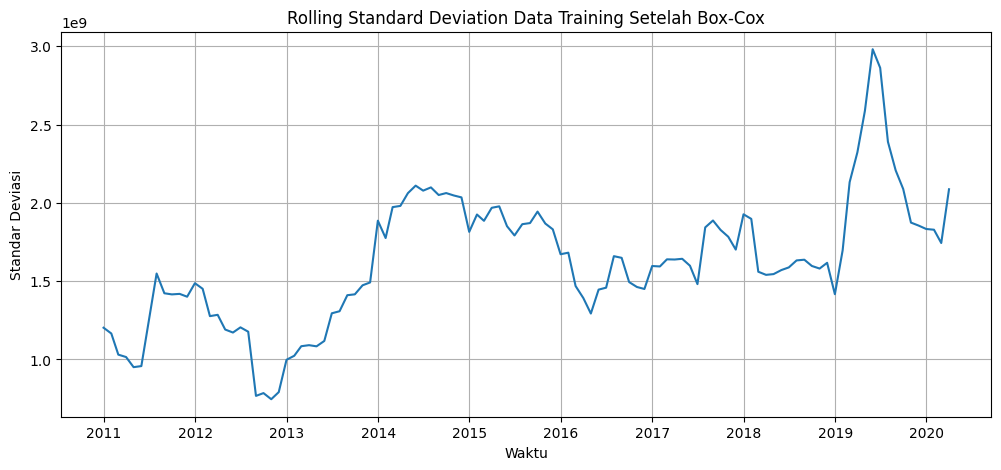

In [32]:
# Rolling standard deviation data training setelah Box-Cox
rolling_std_train_boxcox = (
    df_train['Total_BoxCox']
    .rolling(window=12)
    .std()
)

plt.figure(figsize=(12, 5))

plt.plot(
    df_train['Waktu'],
    rolling_std_train_boxcox
)

plt.title('Rolling Standard Deviation Data Training Setelah Box-Cox')
plt.xlabel('Waktu')
plt.ylabel('Standar Deviasi')
plt.grid(True)
plt.show()

Berdasarkan transformasi Box-Cox pada data training, diperoleh nilai lambda optimal sebesar 1,6484 dengan interval kepercayaan 95% sebesar (0,5088; 2,8076). Karena nilai lambda = 1 masih termasuk dalam interval kepercayaan tersebut, maka transformasi Box-Cox tidak diperlukan pada data training.

In [33]:
from statsmodels.tsa.stattools import adfuller

# Uji ADF data training setelah Box-Cox
hasil_adf_train_boxcox = adfuller(
    df_train['Total_BoxCox'],
    result_object=False
)

print("ADF Statistic :", hasil_adf_train_boxcox[0])
print("p-value       :", hasil_adf_train_boxcox[1])

if hasil_adf_train_boxcox[1] < 0.05:
    print("Kesimpulan: Tolak H0, data training sudah stasioner dalam nilai tengah.")
else:
    print("Kesimpulan: Gagal menolak H0, data training belum stasioner dalam nilai tengah.")

ADF Statistic : -2.2587872786325827
p-value       : 0.1856044512875648
Kesimpulan: Gagal menolak H0, data training belum stasioner dalam nilai tengah.


Hasil uji Augmented Dickey-Fuller pada data training menghasilkan nilai ADF Statistic sebesar -2,2588 dengan p-value sebesar 0,1856. Karena p-value lebih besar dari taraf signifikansi 0,05, maka H0 gagal ditolak. Dengan demikian, data training masih belum stasioner dalam nilai tengah meskipun hasil uji boxcox tidak memerlukan transformasi.

In [34]:
# Differencing orde pertama setelah uji Box-Cox
df_train['Diff_1_BoxCox'] = df_train['Total_BoxCox'].diff()

# Menghilangkan NA akibat differencing
df_train_diff = df_train.dropna().copy()

df_train_diff[['Waktu', 'Total_BoxCox', 'Diff_1_BoxCox']].head()

,Waktu,Total_BoxCox,Diff_1_BoxCox
1,2010-02-28,5.516033e+09,-6.447408e+08
2,2010-03-31,6.591136e+09,1.075103e+09
3,2010-04-30,6.425650e+09,-1.654860e+08
4,2010-05-31,7.194387e+09,7.687366e+08
5,2010-06-30,7.253441e+09,5.905365e+07


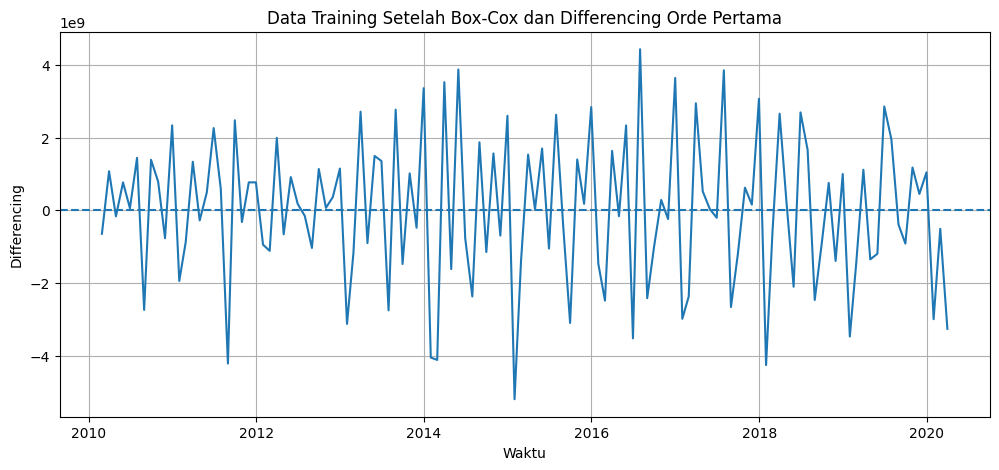

In [35]:
# Plot setelah Box-Cox dan differencing orde pertama
plt.figure(figsize=(12, 5))
plt.plot(
    df_train_diff['Waktu'],
    df_train_diff['Diff_1_BoxCox']
)
plt.axhline(y=0, linestyle='--')
plt.title('Data Training Setelah Box-Cox dan Differencing Orde Pertama')
plt.xlabel('Waktu')
plt.ylabel('Differencing')
plt.grid(True)
plt.show()

In [36]:
# Uji ADF setelah Box-Cox dan differencing orde pertama
hasil_adf_train_diff = adfuller(
    df_train_diff['Diff_1_BoxCox'],
    result_object=False
)

print("ADF Statistic :", hasil_adf_train_diff[0])
print("p-value       :", hasil_adf_train_diff[1])

if hasil_adf_train_diff[1] < 0.05:
    print("Kesimpulan: Tolak H0, data training sudah stasioner dalam nilai tengah.")
else:
    print("Kesimpulan: Gagal menolak H0, data training masih belum stasioner dalam nilai tengah.")

ADF Statistic : -2.906075745128063
p-value       : 0.0446460191140684
Kesimpulan: Tolak H0, data training sudah stasioner dalam nilai tengah.


Pada data training tidak perlu dilakukan transformasi Box-Cox karena nilai lambda 1 masih dalam interval kepercayaan 95% dan setelah uji ADF pada differencing orde pertama diperoleh nilai sebesar -2,9067 dengan p-value sebesar 0,0445. Karena p-value lebih kecil dari taraf signifikansi 0,05, maka H0 ditolak sehingga data training sudah stasioner dalam nilai tengah. Dengan demikian, data training tanpa transformasi Box-Cox dan differencing orde pertama telah stasioner dalam nilai tengah dan ragam.